In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [2]:
from google.colab import files
uploaded = files.upload()

Saving sales.csv to sales.csv


In [3]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,date,sales
0,2023-01-01,50
1,2023-01-02,52
2,2023-01-03,49
3,2023-01-04,55
4,2023-01-05,58


In [4]:
data = df[['sales']].values

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [6]:
X, y = [], []
seq_len = 5
for i in range(seq_len, len(data)):
  X.append(data[i-seq_len:i])
  y.append(data[i])
X = np.array(X)
y = np.array(y)

In [7]:
split = int(0.8*len(X))

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [8]:
from keras.models import Sequential
from keras.layers import Dense, LSTM
model = Sequential()
model.add(LSTM(50, input_shape = (seq_len, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
from keras.callbacks import EarlyStopping

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

In [13]:
model.fit(X_train, y_train, epochs=10, batch_size=5, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0027 - val_loss: 0.0069
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - val_loss: 0.0032
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - val_loss: 0.0012
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0016 - val_loss: 9.2083e-04
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0012 - val_loss: 0.0014


In [15]:
pred = model.predict(X_test)
pred = scaler.inverse_transform(pred)
y_test = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


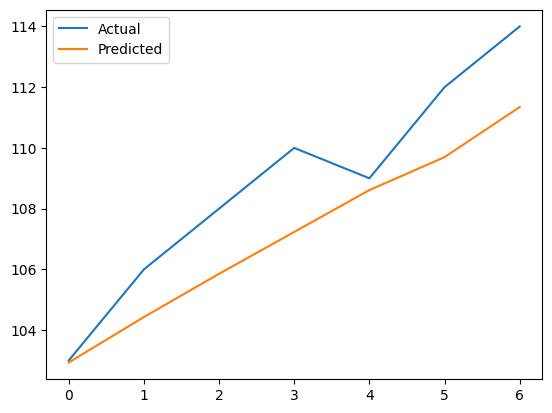

In [16]:
plt.plot(y_test, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

In [17]:
last_seq = data[-5:]
last_seq = np.expand_dims(last_seq, axis=0)
next_val = model.predict(last_seq)
next_val = scaler.inverse_transform(next_val)
print("Next Day Sales: ", next_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
Next Day Sales:  [[112.732796]]
